# GRU + 2D CNN Fusion ECG Classification on PTB-XL

**Model:** Late-fusion of 1D GRU branch (raw ECG) + 2D CNN branch (STFT spectrogram) with CBAM attention  
**References:**
- *An intelligent diagnosis method for CVD based on CNN-CBAM-GRU* (Gong et al., PLOS ONE, 2025)
- *Deep learning for ECG: 1D and 2D representations and multimodal fusion* (Narotamo et al., 2024)

**Task:** Multi-label classification — MI, STTC, CD, HYP

## 0 · Install dependencies

In [1]:
import subprocess, sys
def pip_install(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])
try:
    import torch_ecg
except ImportError:
    pip_install('torch-ecg>=0.0.29')
try:
    import sklearn
except ImportError:
    pip_install('scikit-learn')
try:
    import seaborn
except ImportError:
    pip_install('seaborn')
try:
    import scipy
except ImportError:
    pip_install('scipy')
print('Dependencies ready.')

Dependencies ready.


## 1 · Imports & config

In [2]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy.signal import stft as scipy_stft

from sklearn.metrics import f1_score, multilabel_confusion_matrix

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

NOTEBOOK_DIR = Path('.')
PKL_DIR      = Path('../PTB-XL-ECG')
CKPT_DIR     = NOTEBOOK_DIR / 'checkpoints'
CKPT_DIR.mkdir(exist_ok=True)

CLASS_NAMES  = ['MI', 'STTC', 'CD', 'HYP']
NUM_CLASSES  = len(CLASS_NAMES)

BATCH_SIZE    = 512
EPOCHS        = 50
LR            = 3e-4
WEIGHT_DECAY  = 1e-4
PATIENCE      = 15
WARMUP_EPOCHS = 5
THRESHOLD     = 0.5
USE_FOCAL     = True
FOCAL_GAMMA   = 2.0
FOCAL_ALPHA   = 0.25

DEVICE = (
    'cuda' if torch.cuda.is_available() else
    'mps'  if torch.backends.mps.is_available() else
    'cpu'
)
print(f'Device: {DEVICE}  |  CKPT_DIR: {CKPT_DIR}')

Device: cuda  |  CKPT_DIR: checkpoints


## 2 · Load data

In [3]:
def load_pkl(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

X_train = np.array(load_pkl(PKL_DIR / 'X_train_processed.pickle'), dtype=np.float32).transpose(0,2,1)
y_train = np.array(load_pkl(PKL_DIR / 'y_train_processed.pickle'), dtype=np.float32)
X_val   = np.array(load_pkl(PKL_DIR / 'X_dev_processed.pickle'),   dtype=np.float32).transpose(0,2,1)
y_val   = np.array(load_pkl(PKL_DIR / 'y_dev_processed.pickle'),   dtype=np.float32)
X_test  = np.array(load_pkl(PKL_DIR / 'X_test_processed.pickle'),  dtype=np.float32).transpose(0,2,1)
y_test  = np.array(load_pkl(PKL_DIR / 'y_test_processed.pickle'),  dtype=np.float32)

print(f'Train {X_train.shape}  Val {X_val.shape}  Test {X_test.shape}')

Train (17111, 12, 1000)  Val (2156, 12, 1000)  Test (2163, 12, 1000)


## 3 · NORM undersampling & stratified split

In [4]:
# ── Pool & undersample NORM ──────────────────────────────────────────────────
X_all = np.concatenate([X_train, X_val, X_test], axis=0)
y_all = np.concatenate([y_train, y_val, y_test], axis=0)

NORM_CAP    = 4000
rng         = np.random.default_rng(SEED)
norm_idx    = np.where(y_all.sum(axis=1) == 0)[0]
disease_idx = np.where(y_all.sum(axis=1) > 0)[0]
if len(norm_idx) > NORM_CAP:
    norm_idx = rng.choice(norm_idx, NORM_CAP, replace=False)
bal_idx = np.concatenate([disease_idx, norm_idx])
X_bal, y_bal = X_all[bal_idx], y_all[bal_idx]

norm_bal = (y_bal.sum(axis=1) == 0)
print(f'Balanced dataset: {len(X_bal)} samples  NORM={norm_bal.sum()} ({100*norm_bal.mean():.1f}%)')

try:
    from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable,'-m','pip','install','-q','iterative-stratification'])
    from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

norm_col = norm_bal.astype(np.float32).reshape(-1,1)
y_strat  = np.concatenate([y_bal, norm_col], axis=1)

msss1 = MultilabelStratifiedShuffleSplit(1, test_size=0.15, random_state=SEED)
tv_idx, test_idx = next(msss1.split(X_bal, y_strat))
X_tv, y_tv   = X_bal[tv_idx],   y_bal[tv_idx]
X_test_split = X_bal[test_idx]; y_test_split = y_bal[test_idx]

norm_tv  = (y_tv.sum(axis=1)==0).astype(np.float32).reshape(-1,1)
y_tv_str = np.concatenate([y_tv, norm_tv], axis=1)
msss2 = MultilabelStratifiedShuffleSplit(1, test_size=0.176, random_state=SEED)
tr_idx2, val_idx2 = next(msss2.split(X_tv, y_tv_str))
X_train_split = X_tv[tr_idx2];  y_train_split = y_tv[tr_idx2]
X_val_split   = X_tv[val_idx2]; y_val_split   = y_tv[val_idx2]

print(f'Train {len(X_train_split)} | Val {len(X_val_split)} | Test {len(X_test_split)}')

Balanced dataset: 16347 samples  NORM=4000 (24.5%)
Train 11474 | Val 2424 | Test 2449


## 4 · Fusion dataset (raw ECG + spectrogram)

In [5]:
def ecg_to_spec(ecg, nperseg=64, noverlap=48, img_size=64):
    specs = []
    for lead in ecg:
        _, _, Zxx = scipy_stft(lead, nperseg=nperseg, noverlap=noverlap)
        mag = np.log1p(np.abs(Zxx)).astype(np.float32)
        t   = torch.tensor(mag).unsqueeze(0).unsqueeze(0)
        t   = F.interpolate(t, size=(img_size, img_size), mode='bilinear', align_corners=False)
        specs.append(t.squeeze().numpy())
    spec = np.stack(specs).astype(np.float32)
    mn, mx = spec.min(), spec.max()
    return (spec - mn) / (mx - mn + 1e-8)

class ECGFusionDataset(Dataset):
    """Returns (raw_ecg, spectrogram, label) for dual-branch model."""
    def __init__(self, X, y, img_size=64):
        self.X = torch.from_numpy(X)   # (N, 12, 1000)
        self.y = torch.from_numpy(y)
        self.img_size = img_size
    def __len__(self): return len(self.X)
    def __getitem__(self, idx):
        x_raw  = self.X[idx]                                     # (12, 1000)
        x_spec = torch.from_numpy(ecg_to_spec(x_raw.numpy(), img_size=self.img_size))
        return x_raw, x_spec, self.y[idx]

_r, _s, _l = ECGFusionDataset(X_train_split[:2], y_train_split[:2])[0]
print(f'raw: {_r.shape}  spec: {_s.shape}  label: {_l.shape}')

raw: torch.Size([12, 1000])  spec: torch.Size([12, 64, 64])  label: torch.Size([4])


## 5 · Loss function

In [6]:
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha, self.gamma = alpha, gamma

    def forward(self, logits, targets):
        bce     = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        p_t     = torch.exp(-bce)
        alpha_t = targets * self.alpha + (1 - targets) * (1 - self.alpha)
        return (alpha_t * (1 - p_t) ** self.gamma * bce).mean()

def make_criterion(y_labels):
    if USE_FOCAL:
        return FocalLoss(FOCAL_ALPHA, FOCAL_GAMMA)
    pos = y_labels.sum(0); neg = len(y_labels) - pos
    pw  = torch.tensor(neg / (pos + 1e-8), dtype=torch.float32).to(DEVICE)
    return nn.BCEWithLogitsLoss(pos_weight=pw)

criterion = make_criterion(y_train_split)
print(f'Loss: {"Focal" if USE_FOCAL else "Weighted BCE"}')

Loss: Focal


## 6 · Model — GRU + 2D CNN with CBAM Fusion

Two independent branches process complementary representations:
- **1D GRU branch**: CNN downsampler → BiGRU captures morphological time-series dependencies
- **2D CNN branch**: stacked Conv2d on STFT spectrogram → CBAM attention → spatial features
- **Late fusion**: feature concatenation → MLP classifier

In [7]:
class CBAM(nn.Module):
    """Convolutional Block Attention Module."""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.ca_avg = nn.AdaptiveAvgPool2d(1)
        self.ca_max = nn.AdaptiveMaxPool2d(1)
        self.ca_fc  = nn.Sequential(
            nn.Linear(channels, channels//reduction), nn.ReLU(),
            nn.Linear(channels//reduction, channels))
        self.sa_conv = nn.Conv2d(2, 1, kernel_size=7, padding=3)

    def forward(self, x):
        b, c, _, _ = x.shape
        avg = self.ca_fc(self.ca_avg(x).view(b, c))
        mx  = self.ca_fc(self.ca_max(x).view(b, c))
        x   = x * torch.sigmoid(avg + mx).view(b, c, 1, 1)
        s   = torch.cat([x.mean(1,keepdim=True), x.max(1,keepdim=True).values], 1)
        return x * torch.sigmoid(self.sa_conv(s))


class GRU_2DCNN_Fusion(nn.Module):
    """
    Late-fusion dual-branch model:
      • 1D GRU branch  — raw (12, 1000) ECG  → temporal features
      • 2D CNN branch  — STFT (12, 64, 64)   → spectro-spatial features + CBAM
    Branches are concatenated and fed to an MLP classifier.

    References:
      - CNN-CBAM-GRU (Gong et al., 2025, PLOS ONE)
      - 'Deep learning for ECG: 1D and 2D representations and multimodal fusion'
        (Narotamo et al., 2024, Biomedical Signal Processing and Control)
    """
    def __init__(self, n_classes=NUM_CLASSES, gru_hidden=128, cnn_ch=64):
        super().__init__()
        # ── 1D GRU branch ─────────────────────────────────────────────────
        self.gru_cnn = nn.Sequential(
            nn.Conv1d(12, 64, 7, padding=3), nn.BatchNorm1d(64), nn.ReLU(),
            nn.MaxPool1d(4),
            nn.Conv1d(64, 128, 5, padding=2), nn.BatchNorm1d(128), nn.ReLU(),
            nn.MaxPool1d(5),   # → (N, 128, 50)
        )
        self.gru = nn.GRU(128, gru_hidden, num_layers=2, bidirectional=True,
                          batch_first=True, dropout=0.3)
        gru_dim = gru_hidden * 2   # 256

        # ── 2D CNN branch + CBAM ──────────────────────────────────────────
        self.spec_cnn = nn.Sequential(
            nn.Conv2d(12, cnn_ch,   3, padding=1), nn.BatchNorm2d(cnn_ch),   nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(cnn_ch, cnn_ch*2, 3, padding=1), nn.BatchNorm2d(cnn_ch*2), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(cnn_ch*2, cnn_ch*4, 3, padding=1), nn.BatchNorm2d(cnn_ch*4), nn.ReLU(), nn.MaxPool2d(2),
        )   # → (N, 256, 8, 8)
        self.cbam     = CBAM(cnn_ch * 4)
        self.spec_pool = nn.AdaptiveAvgPool2d(1)
        cnn_dim = cnn_ch * 4   # 256

        # ── Fusion MLP ────────────────────────────────────────────────────
        self.fusion = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(gru_dim + cnn_dim, 128), nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, n_classes),
        )

    def forward(self, x_raw, x_spec):
        # GRU branch
        h = self.gru_cnn(x_raw)            # (N, 128, 50)
        gru_out, _ = self.gru(h.permute(0,2,1))  # (N, 50, 256)
        gru_feat = gru_out.mean(1)         # (N, 256)

        # CNN branch
        c = self.spec_cnn(x_spec)          # (N, 256, 8, 8)
        c = self.cbam(c)
        cnn_feat = self.spec_pool(c).flatten(1)   # (N, 256)

        return self.fusion(torch.cat([gru_feat, cnn_feat], 1))   # logits

model = GRU_2DCNN_Fusion().to(DEVICE)
total = sum(p.numel() for p in model.parameters())
print(f'GRU_2DCNN_Fusion  |  params: {total:,}')

GRU_2DCNN_Fusion  |  params: 993,143


## 7 · Training

In [8]:
def compute_metrics(probs, targets, threshold=THRESHOLD):
    preds = (probs >= threshold).astype(int)
    mcm   = multilabel_confusion_matrix(targets.astype(int), preds)
    results = {}
    for i, cls in enumerate(CLASS_NAMES):
        tn, fp, fn, tp = mcm[i].ravel()
        results[cls] = dict(
            sensitivity = tp/(tp+fn+1e-8),
            specificity = tn/(tn+fp+1e-8),
            accuracy    = (tp+tn)/(tp+tn+fp+fn+1e-8),
            f1          = 2*tp/(2*tp+fp+fn+1e-8),
        )
    for m in ('sensitivity','specificity','accuracy','f1'):
        results[f'macro_{m}'] = np.mean([results[c][m] for c in CLASS_NAMES])
    return results

In [9]:
def run_epoch(loader, model, criterion, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss, n_batches = 0.0, 0
    all_probs, all_targets = [], []
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for x_raw, x_spec, y_b in loader:
            x_raw, x_spec, y_b = x_raw.to(DEVICE), x_spec.to(DEVICE), y_b.to(DEVICE)
            logits = model(x_raw, x_spec)
            loss   = criterion(logits, y_b)
            if training:
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0); optimizer.step()
            total_loss += loss.item(); n_batches += 1
            all_probs.append(torch.sigmoid(logits).detach().cpu().numpy())
            all_targets.append(y_b.detach().cpu().numpy())
    return total_loss/n_batches, np.concatenate(all_probs), np.concatenate(all_targets)

IMG_SIZE = 64
tr_loader  = DataLoader(ECGFusionDataset(X_train_split, y_train_split, IMG_SIZE),
                        batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader = DataLoader(ECGFusionDataset(X_val_split,   y_val_split,   IMG_SIZE),
                        batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
te_loader  = DataLoader(ECGFusionDataset(X_test_split,  y_test_split,  IMG_SIZE),
                        batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=5)

best_f1, best_state, no_improve = -1.0, None, 0
history = {'train_loss':[], 'val_loss':[], 'val_f1':[]}

for epoch in range(1, EPOCHS+1):
    tr_loss, _,  _   = run_epoch(tr_loader,  model, criterion, optimizer)
    val_loss, vp, vt = run_epoch(val_loader, model, criterion)
    scheduler.step(val_loss)
    vf1 = compute_metrics(vp, vt)['macro_f1']
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(vf1)
    if epoch > WARMUP_EPOCHS:
        if vf1 > best_f1:
            best_f1 = vf1
            best_state = {k: v.cpu().clone() for k,v in model.state_dict().items()}
            torch.save(best_state, CKPT_DIR / 'best_model.pt')
            no_improve = 0
        else:
            no_improve += 1
        if no_improve >= PATIENCE:
            print(f'Early stop at epoch {epoch}  (best val F1={best_f1:.4f})')
            break
    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d} | tr_loss={tr_loss:.4f} | val_loss={val_loss:.4f} | val_F1={vf1:.4f}')

if best_state:
    model.load_state_dict({k: v.to(DEVICE) for k,v in best_state.items()})

_, test_probs, test_targets  = run_epoch(te_loader,  model, criterion)
_, val_probs_tune, val_targets_tune = run_epoch(val_loader, model, criterion)
test_metrics = compute_metrics(test_probs, test_targets)
cv_test_probs, cv_test_targets = val_probs_tune, val_targets_tune

print(f'\nTest set ({len(test_probs)} samples):')
for cls in CLASS_NAMES:
    print(f'  {cls:<5} F1={test_metrics[cls]["f1"]:.4f}')
print(f'  Macro F1={test_metrics["macro_f1"]:.4f}')

Epoch   1 | tr_loss=0.0629 | val_loss=0.0574 | val_F1=0.0000
Epoch   5 | tr_loss=0.0395 | val_loss=0.0372 | val_F1=0.5161
Epoch  10 | tr_loss=0.0335 | val_loss=0.0337 | val_F1=0.6285
Epoch  15 | tr_loss=0.0311 | val_loss=0.0329 | val_F1=0.6579
Epoch  20 | tr_loss=0.0277 | val_loss=0.0342 | val_F1=0.6820
Epoch  25 | tr_loss=0.0252 | val_loss=0.0339 | val_F1=0.6754
Epoch  30 | tr_loss=0.0222 | val_loss=0.0353 | val_F1=0.6986
Epoch  35 | tr_loss=0.0201 | val_loss=0.0372 | val_F1=0.7044
Epoch  40 | tr_loss=0.0187 | val_loss=0.0385 | val_F1=0.7036
Epoch  45 | tr_loss=0.0179 | val_loss=0.0388 | val_F1=0.6973
Epoch  50 | tr_loss=0.0177 | val_loss=0.0396 | val_F1=0.7032

Test set (2449 samples):
  MI    F1=0.6741
  STTC  F1=0.7336
  CD    F1=0.7460
  HYP   F1=0.6145
  Macro F1=0.6920


## 8 · Training curves

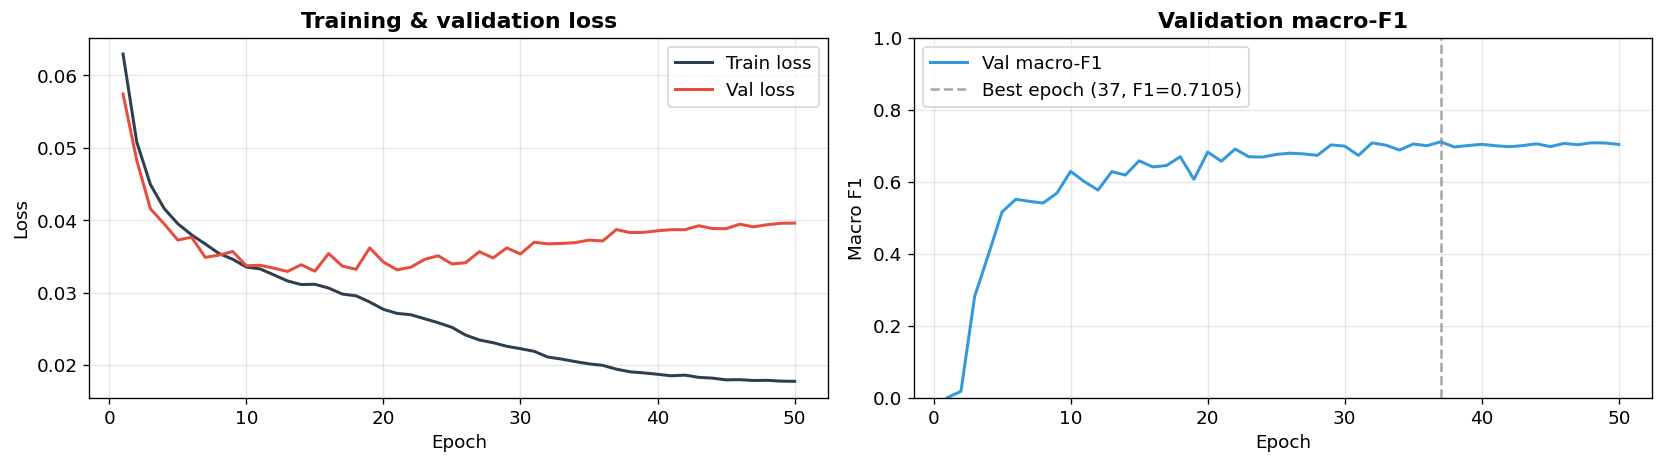

In [10]:
epochs_ran = list(range(1, len(history['train_loss'])+1))
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
ax.plot(epochs_ran, history['train_loss'], label='Train loss', color='#2c3e50', linewidth=1.8)
ax.plot(epochs_ran, history['val_loss'],   label='Val loss',   color='#e74c3c', linewidth=1.8)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Training & validation loss', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(epochs_ran, history['val_f1'], label='Val macro-F1', color='#3498db', linewidth=1.8)
best_ep = int(np.argmax(history['val_f1']))
ax.axvline(best_ep+1, color='grey', linestyle='--', alpha=0.7,
           label=f'Best epoch ({best_ep+1}, F1={max(history["val_f1"]):.4f})')
ax.set_xlabel('Epoch'); ax.set_ylabel('Macro F1')
ax.set_title('Validation macro-F1', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylim(0,1)
plt.tight_layout()
plt.savefig(CKPT_DIR / 'training_curves.png', bbox_inches='tight')
plt.show()

## 9 · Evaluation

In [11]:
print(f'Test set: {len(test_probs)} samples')
print(f'{"Class":<6} {"Sensitivity":>12} {"Specificity":>12} {"Accuracy":>10} {"F1":>8}')
print('─'*52)
for cls in CLASS_NAMES:
    m = test_metrics[cls]
    print(f'{cls:<6} {m["sensitivity"]:>12.4f} {m["specificity"]:>12.4f} {m["accuracy"]:>10.4f} {m["f1"]:>8.4f}')
print('─'*52)
print(f'{"Macro":<6} {test_metrics["macro_sensitivity"]:>12.4f} {test_metrics["macro_specificity"]:>12.4f} '
      f'{test_metrics["macro_accuracy"]:>10.4f} {test_metrics["macro_f1"]:>8.4f}')

Test set: 2449 samples
Class   Sensitivity  Specificity   Accuracy       F1
────────────────────────────────────────────────────
MI           0.5492       0.9594     0.8216   0.6741
STTC         0.6865       0.9121     0.8395   0.7336
CD           0.6726       0.9440     0.8624   0.7460
HYP          0.5126       0.9698     0.8955   0.6145
────────────────────────────────────────────────────
Macro        0.6052       0.9463     0.8547   0.6920


## 9b · Threshold tuning

Per-class threshold tuning (val set — no test leakage):
Class   Best thresh    F1@0.50    F1@best
------------------------------------------
MI             0.29     0.6980     0.7648
STTC           0.38     0.7198     0.7569
CD             0.47     0.7783     0.7882
HYP            0.41     0.6458     0.6754


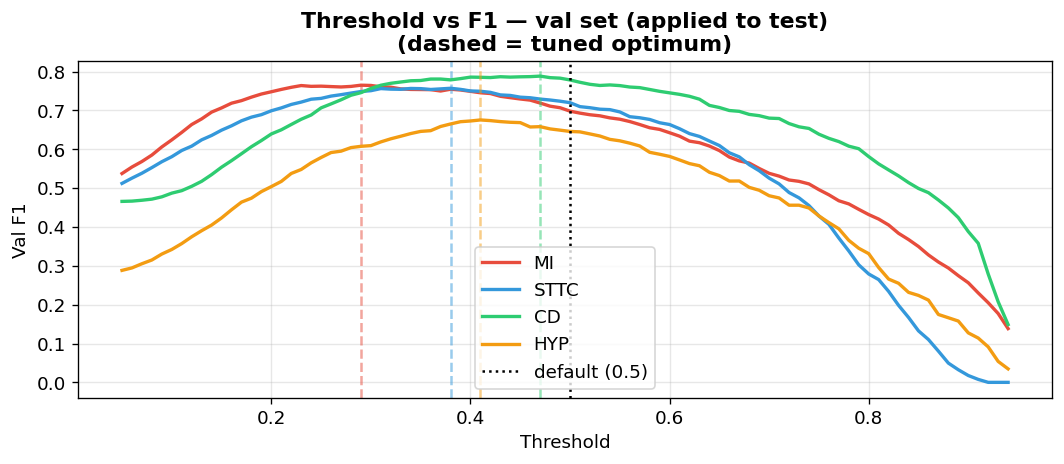


Test — tuned thresholds vs default (0.5):
Class    F1@0.50   F1@tuned     Δ F1
-------------------------------------
MI        0.6741     0.7533 +0.0792
STTC      0.7336     0.7594 +0.0259
CD        0.7460     0.7579 +0.0119
HYP       0.6145     0.6305 +0.0160
-------------------------------------
Macro     0.6920     0.7253 +0.0332


In [12]:
thresholds_grid  = np.arange(0.05, 0.95, 0.01)
best_thresholds  = {}
thresh_f1_curves = {}

print('Per-class threshold tuning (val set — no test leakage):')
print(f'{"Class":<6} {"Best thresh":>12} {"F1@0.50":>10} {"F1@best":>10}')
print('-'*42)
for i, cls in enumerate(CLASS_NAMES):
    f1s    = [f1_score(cv_test_targets[:,i], (cv_test_probs[:,i]>=t).astype(int), zero_division=0)
              for t in thresholds_grid]
    best_t = thresholds_grid[np.argmax(f1s)]
    f1_50  = f1_score(cv_test_targets[:,i], (cv_test_probs[:,i]>=0.5).astype(int), zero_division=0)
    best_thresholds[cls]  = best_t
    thresh_f1_curves[cls] = f1s
    print(f'{cls:<6} {best_t:>12.2f} {f1_50:>10.4f} {max(f1s):>10.4f}')

fig, ax = plt.subplots(figsize=(9,4))
colors = ['#e74c3c','#3498db','#2ecc71','#f39c12']
for cls, col in zip(CLASS_NAMES, colors):
    ax.plot(thresholds_grid, thresh_f1_curves[cls], label=cls, color=col, linewidth=2)
    ax.axvline(best_thresholds[cls], color=col, linestyle='--', alpha=0.5)
ax.axvline(0.5, color='black', linestyle=':', linewidth=1.5, label='default (0.5)')
ax.set_xlabel('Threshold'); ax.set_ylabel('Val F1')
ax.set_title('Threshold vs F1 — val set (applied to test)\n(dashed = tuned optimum)', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CKPT_DIR / 'threshold_tuning.png', bbox_inches='tight')
plt.show()

tuned_arr  = np.array([best_thresholds[c] for c in CLASS_NAMES])
preds_tuned = (test_probs >= tuned_arr).astype(int)
mcm_tuned   = multilabel_confusion_matrix(test_targets.astype(int), preds_tuned)
test_metrics_tuned = {}
for i, cls in enumerate(CLASS_NAMES):
    tn,fp,fn,tp = mcm_tuned[i].ravel()
    test_metrics_tuned[cls] = dict(
        sensitivity=tp/(tp+fn+1e-8), specificity=tn/(tn+fp+1e-8),
        accuracy=(tp+tn)/(tp+tn+fp+fn+1e-8), f1=2*tp/(2*tp+fp+fn+1e-8))
for m in ('sensitivity','specificity','accuracy','f1'):
    test_metrics_tuned[f'macro_{m}'] = np.mean([test_metrics_tuned[c][m] for c in CLASS_NAMES])

print(f'\nTest — tuned thresholds vs default (0.5):')
print(f'{"Class":<6} {"F1@0.50":>9} {"F1@tuned":>10} {"Δ F1":>8}')
print('-'*37)
for cls in CLASS_NAMES:
    d = test_metrics_tuned[cls]['f1'] - test_metrics[cls]['f1']
    print(f'{cls:<6} {test_metrics[cls]["f1"]:>9.4f} {test_metrics_tuned[cls]["f1"]:>10.4f} {d:>+7.4f}')
print('-'*37)
print(f'{"Macro":<6} {test_metrics["macro_f1"]:>9.4f} {test_metrics_tuned["macro_f1"]:>10.4f} '
      f'{test_metrics_tuned["macro_f1"]-test_metrics["macro_f1"]:>+7.4f}')

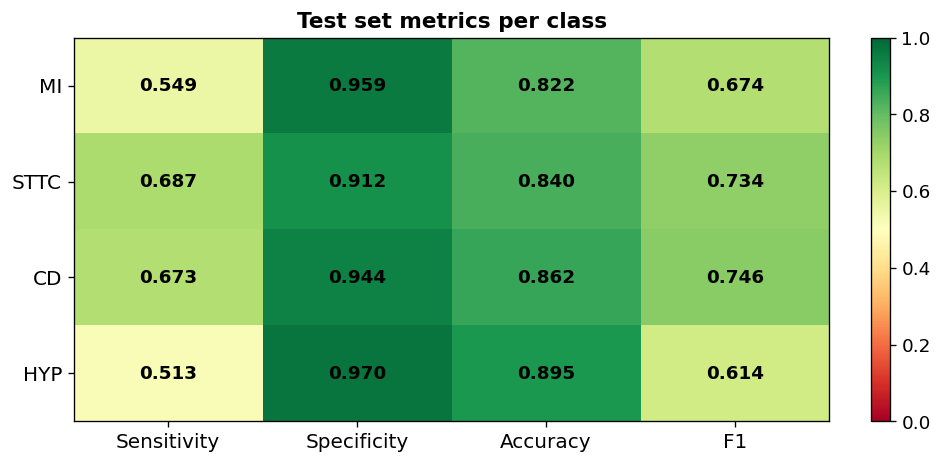

In [13]:
metric_names = ['Sensitivity','Specificity','Accuracy','F1']
metric_keys  = ['sensitivity','specificity','accuracy','f1']
data = np.array([[test_metrics[cls][k] for k in metric_keys] for cls in CLASS_NAMES])
fig, ax = plt.subplots(figsize=(8,4))
im = ax.imshow(data, vmin=0, vmax=1, cmap='RdYlGn', aspect='auto')
ax.set_xticks(range(len(metric_names))); ax.set_xticklabels(metric_names, fontsize=12)
ax.set_yticks(range(len(CLASS_NAMES)));  ax.set_yticklabels(CLASS_NAMES, fontsize=12)
for i in range(len(CLASS_NAMES)):
    for j in range(len(metric_names)):
        ax.text(j, i, f'{data[i,j]:.3f}', ha='center', va='center', fontsize=11, fontweight='bold')
ax.set_title('Test set metrics per class', fontweight='bold', fontsize=13)
plt.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout()
plt.savefig(CKPT_DIR / 'metrics_heatmap.png', bbox_inches='tight')
plt.show()

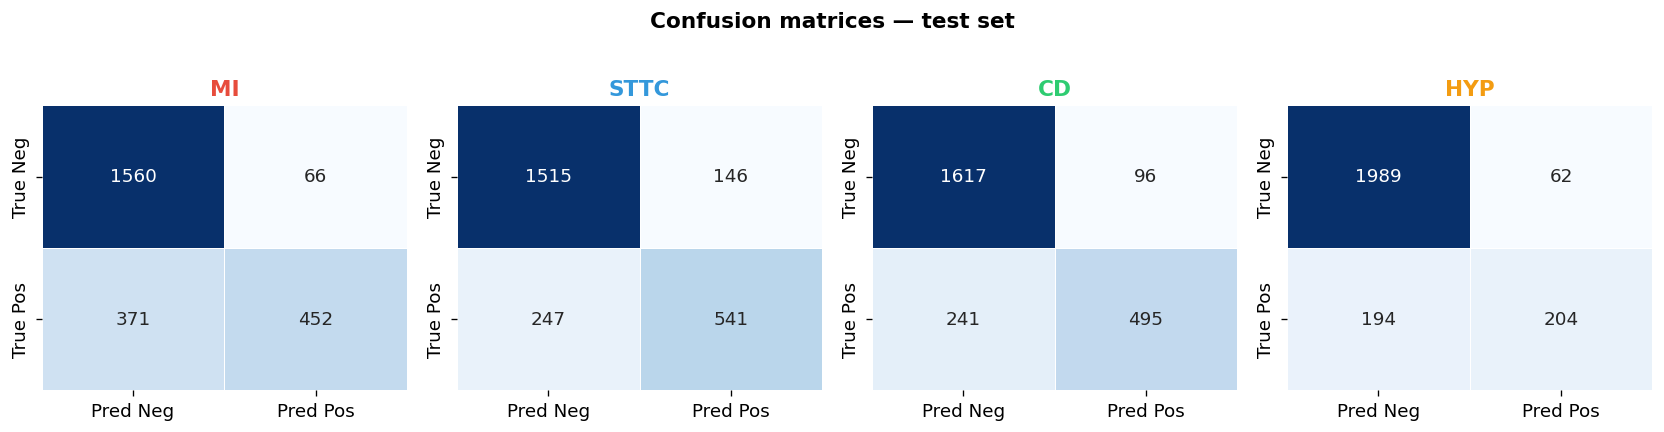

In [14]:
preds_bin = (test_probs >= THRESHOLD).astype(int)
mcm = multilabel_confusion_matrix(test_targets.astype(int), preds_bin)
COLORS = ['#e74c3c','#3498db','#2ecc71','#f39c12']
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(14,3.5))
for i,(cls,ax) in enumerate(zip(CLASS_NAMES,axes)):
    sns.heatmap(mcm[i], annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred Neg','Pred Pos'], yticklabels=['True Neg','True Pos'],
                cbar=False, linewidths=0.5)
    ax.set_title(cls, fontweight='bold', color=COLORS[i], fontsize=13)
plt.suptitle('Confusion matrices — test set', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(CKPT_DIR / 'confusion_matrices.png', bbox_inches='tight')
plt.show()

## 10 · XAI — GradCAM on 2D CNN branch

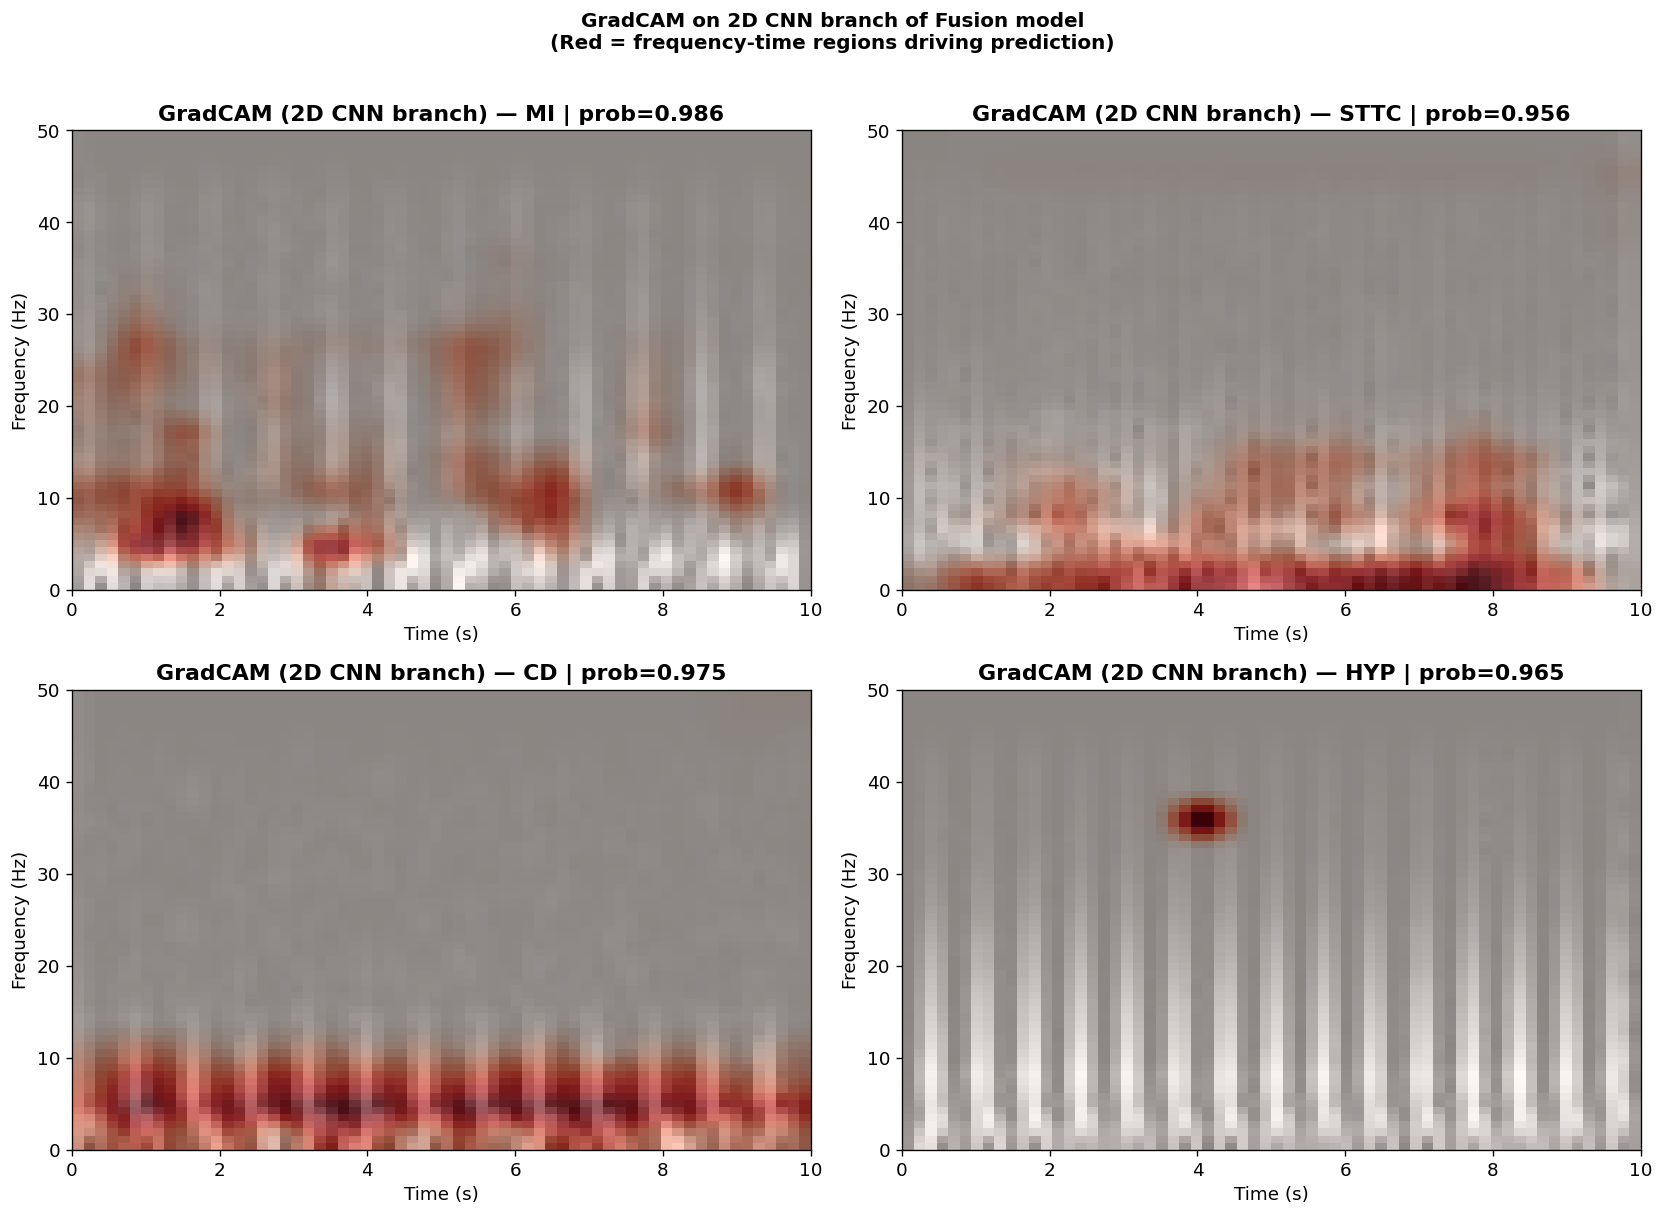

In [15]:
# GradCAM on the 2D CNN branch of the fusion model
class GradCAM2D_Fusion:
    def __init__(self, model, target_layer):
        self.model = model; self.activations = None; self.gradients = None
        self._fh = target_layer.register_forward_hook(lambda m,i,o: setattr(self,'activations',o.detach()))
        self._bh = target_layer.register_full_backward_hook(
            lambda m,gi,go: setattr(self,'gradients',go[0].detach()))
    def generate(self, x_raw, x_spec, cls_idx):
        was = self.model.training; self.model.train()
        x_raw = x_raw.requires_grad_(False)
        x_spec = x_spec.requires_grad_(True)
        logits = self.model(x_raw, x_spec); self.model.zero_grad()
        logits[0, cls_idx].backward()
        if not was: self.model.eval()
        w   = self.gradients.mean(dim=(-2,-1), keepdim=True)
        cam = torch.relu((w * self.activations).sum(1)).squeeze().cpu().numpy()
        return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    def remove_hooks(self): self._fh.remove(); self._bh.remove()

# Target: last CBAM conv output — last layer of spec_cnn
target_layer = model.spec_cnn[-2]   # last Conv2d before final MaxPool
grad_cam = GradCAM2D_Fusion(model, target_layer)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (cls_idx, cls) in zip(axes.flat, enumerate(CLASS_NAMES)):
    mask = test_targets[:, cls_idx] == 1
    if not mask.any(): ax.set_title(f'{cls}: no samples'); continue
    best_idx = np.argmax(test_probs[mask, cls_idx])
    raw_ecg  = X_test_split[np.where(mask)[0][best_idx]]
    spec     = ecg_to_spec(raw_ecg, img_size=IMG_SIZE)
    x_r  = torch.tensor(raw_ecg[np.newaxis]).to(DEVICE)
    x_s  = torch.tensor(spec[np.newaxis]).to(DEVICE)
    cam  = grad_cam.generate(x_r, x_s, cls_idx)
    cam_r = F.interpolate(torch.tensor(cam).unsqueeze(0).unsqueeze(0).float(),
                           size=(IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False).squeeze().numpy()
    ax.imshow(spec[1], origin='lower', aspect='auto', cmap='gray', extent=[0,10,0,50])
    ax.imshow(cam_r, origin='lower', aspect='auto', cmap='Reds', alpha=0.55, extent=[0,10,0,50])
    ax.set_title(f'GradCAM (2D CNN branch) — {cls} | prob={test_probs[np.where(mask)[0][best_idx], cls_idx]:.3f}',
                 fontweight='bold')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('Frequency (Hz)')

grad_cam.remove_hooks()
plt.suptitle('GradCAM on 2D CNN branch of Fusion model\n(Red = frequency-time regions driving prediction)',
             fontweight='bold', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(CKPT_DIR / 'xai_gradcam_cnn_branch.png', bbox_inches='tight')
plt.show()

## 11 · Summary

In [16]:
print('='*60)
print('  FINAL SUMMARY — Fusion_GRU_2DCNN_ECG')
print('='*60)
print(f'Dataset: {len(X_bal)} samples  (NORM undersampled to {NORM_CAP})')
print(f'Split:   {len(X_train_split)} train / {len(X_val_split)} val / {len(X_test_split)} test')

print()
print('Test performance (default threshold):')
print(f'{"Class":<6} {"Sensitivity":>12} {"Specificity":>12} {"Accuracy":>10} {"F1":>8}')
print('-'*52)
for cls in CLASS_NAMES:
    m = test_metrics[cls]
    print(f'{cls:<6} {m["sensitivity"]:>12.4f} {m["specificity"]:>12.4f} {m["accuracy"]:>10.4f} {m["f1"]:>8.4f}')
print('-'*52)
print(f'{"Macro":<6} {test_metrics["macro_sensitivity"]:>12.4f} {test_metrics["macro_specificity"]:>12.4f} '
      f'{test_metrics["macro_accuracy"]:>10.4f} {test_metrics["macro_f1"]:>8.4f}')
print()
for f in sorted(CKPT_DIR.iterdir()):
    if f.is_file():
        print(f'  {f.name:<45} {f.stat().st_size/1024:7.1f} KB')

  FINAL SUMMARY — Fusion_GRU_2DCNN_ECG
Dataset: 16347 samples  (NORM undersampled to 4000)
Split:   11474 train / 2424 val / 2449 test

Test performance (default threshold):
Class   Sensitivity  Specificity   Accuracy       F1
----------------------------------------------------
MI           0.5492       0.9594     0.8216   0.6741
STTC         0.6865       0.9121     0.8395   0.7336
CD           0.6726       0.9440     0.8624   0.7460
HYP          0.5126       0.9698     0.8955   0.6145
----------------------------------------------------
Macro        0.6052       0.9463     0.8547   0.6920

  best_model.pt                                  3902.6 KB
  confusion_matrices.png                           33.9 KB
  metrics_heatmap.png                              44.1 KB
  threshold_tuning.png                             89.1 KB
  training_curves.png                              75.0 KB
  xai_gradcam_cnn_branch.png                      118.9 KB
